In [7]:
import gdown
import pandas as pd

# Download entire telecom folder from Google Drive
gdown.download_folder(
    "https://drive.google.com/drive/folders/1BNXNc7faBZW6Pd5zAL99j85ADNIZtfzS",
    quiet=False,
    use_cookies=False
)

import pandas as pd
clients_data = pd.read_csv('telecom/Client.csv')
records_data = pd.read_csv('telecom/Record.csv')

Retrieving folder contents


Processing file 1bBr79H7v3UkmUsr4chfNfUqk6FhQG0Ck Client.csv
Processing file 1GJaihaVULZ42qmms4lZD3zjGzCzURKem Record.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1bBr79H7v3UkmUsr4chfNfUqk6FhQG0Ck
To: /content/telecom/Client.csv
100%|██████████| 17.9M/17.9M [00:00<00:00, 89.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1GJaihaVULZ42qmms4lZD3zjGzCzURKem
To: /content/telecom/Record.csv
100%|██████████| 30.2M/30.2M [00:00<00:00, 42.4MB/s]
Download completed


In [8]:



# Merge on Customer_ID, then move Customer_ID to the front and churn to the end
df = pd.merge(clients_data, records_data, on='Customer_ID')

cols = ['Customer_ID'] + [c for c in df.columns if c not in ('Customer_ID', 'churn')] + ['churn']
df = df[cols]

df.head()

,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,...,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,months,churn
0,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,...,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,61,1
1,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,...,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,56,0
2,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,...,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,58,1
3,1000004,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,...,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,60,0
4,1000005,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,...,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,57,0


## Customer Churn Predisction

This study uses a classification model to predict the probability of a client to churn (stop using our sevices).

Target Variable = churn

# Data Analysis

## class balance check

churn
0    50438
1    49562
Name: count, dtype: int64
churn
0    0.50438
1    0.49562
Name: proportion, dtype: float64


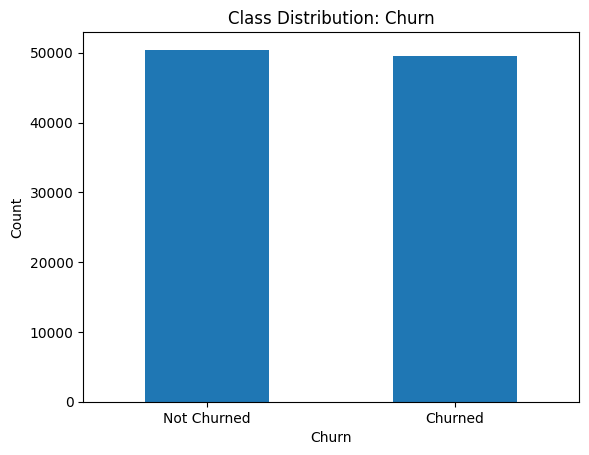

In [9]:
import matplotlib.pyplot as plt

# Counts and proportions of each class
print(df['churn'].value_counts())
print(df['churn'].value_counts(normalize=True))

df['churn'].value_counts().plot(kind='bar')
plt.title('Class Distribution: Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Churned', 'Churned'], rotation=0)
plt.show()


Since the classes are balanced (~50/50), accuracy is a meaningful baseline metric. However, we also report [precision/recall/AUC] because false negatives (missed churners) and false positives (unnecessary retention spend) have different business costs.

## Cost of churn figure

Question: how much revenue did we watch walk out the door, the revenue tied to customers that churned.

Cost = count(churners) x (average revenue in churners)

### features in action
- churn (target) = churn
- average monthly revenue (charge amount) = rev_Mean


In [10]:
avg_revenue_per_churner = df.loc[df['churn'] == 1, 'rev_Mean'].mean()
n_churners = (df['churn'] == 1).sum()


cost_of_churn = n_churners * avg_revenue_per_churner  # monthly
annual_cost_of_churn = cost_of_churn * 12  # if rev_Mean is monthly
print("Monthly Cost of churn",cost_of_churn)
print("Anuall Cost of churn ",annual_cost_of_churn)


Monthly Cost of churn 2885057.246447842
Anuall Cost of churn  34620686.9573741



Leading to a conclusion that churn prediction per client is a significant study.

In [11]:
corr_with_churn = df.corr(numeric_only=True)['churn'].drop('churn')
corr_with_churn = corr_with_churn.sort_values(key=abs, ascending=False)
corr_with_churn

,churn
eqpdays,0.112691
hnd_price,-0.103184
totmrc_Mean,-0.068558
mou_Mean,-0.057027
mou_cvce_Mean,-0.052042
...,...
numbcars,0.002392
callfwdv_Mean,-0.002248
datovr_Mean,-0.001290
recv_sms_Mean,-0.000812


No single variable strongly predicts churn in isolation (max |correlation| ≈ 0.11), suggesting churn results from combinations of behaviors rather than one dominant factor, motivating a tree-based model that can capture these interactions.

Tree-based models naturally capture interactions between variables through sequential splits, making them well-suited for churn, where no single variable is strongly predictive on its own.

In [12]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

,0
numbcars,49366
dwllsize,38308
HHstatin,37923
ownrent,33706
dwlltype,31909
lor,30190
income,25436
adults,23019
infobase,22079
hnd_webcap,10189


In [13]:
from sklearn.impute import SimpleImputer

num_cols = df.select_dtypes(include='number').columns.drop('churn')
cat_cols = df.select_dtypes(exclude='number').columns

# Numeric: median imputation
df[num_cols] = SimpleImputer(strategy='median').fit_transform(df[num_cols])

# Categorical: fill with explicit "Unknown" category
df[cat_cols] = df[cat_cols].fillna('Unknown')


In [14]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

,0


High missingness (25-49%): numbcars, dwllsize, HHstatin, ownrent, dwlltype, lor, income, adults, infobase. These are largely third-party demographic/lifestyle attributes (household size, dwelling type, income bracket, etc.), likely unavailable because the data vendor could not match every customer to external records. Because absence may itself correlate with customer segment, these were retained and missing values recoded as an explicit "Unknown" category (for categoricals) rather than imputed, preserving any signal in the missingness itself.

Moderate missingness (5-10%): hnd_webcap, prizm_social_one. Same treatment, filled with "Unknown".

Low missingness (<3%): avg6mou, avg6rev, avg6qty, the kid* indicators, marital, rv, truck, forgntvl, ethnic, creditcd, change_mou, change_rev, hnd_price, vceovr_Mean. With such a small share of records affected, these were imputed simply: numeric columns with the median (robust to outliers/skew) and categorical columns with "Unknown" (or mode where the category is well-defined).

In [15]:
customer_ids = df['Customer_ID']
df = df.drop(columns='Customer_ID')

## One hot encoding

One-hot encoding is necessary because trees (and most sklearn models) require numeric input and cannot directly process categorical values like "Married" or "Northeast." One-hot encoding converts each category into its own binary (0/1) column, indicating whether a row belongs to that category. This avoids implying a false numeric order between categories — for example, label-encoding marital as 1, 2, 3 would wrongly suggest one category is mathematically "greater" than another. The resulting binary columns also become clean yes/no split points for the decision tree (e.g., "is area_Northeast = 1?"), preserving all categorical information at the cost of additional columns.

In [16]:
cat_cols = df.select_dtypes(exclude='number').columns
data_encoded = pd.get_dummies(df, columns=cat_cols)
data_encoded.head()

,uniqsubs,actvsubs,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,...,kid6_10_Y,kid11_15_U,kid11_15_Unknown,kid11_15_Y,kid16_17_U,kid16_17_Unknown,kid16_17_Y,creditcd_N,creditcd_Unknown,creditcd_Y
0,2.0,1.0,1652.0,4228.00000,1504.62,1453.44,4085.00,1602.0,29.66,83.37,...,False,True,False,False,True,False,False,False,False,True
1,1.0,1.0,14654.0,26400.00000,2851.68,2833.88,26367.00,14624.0,51.53,479.40,...,False,True,False,False,True,False,False,False,False,True
2,1.0,1.0,7903.0,24385.05333,2155.91,1934.47,24303.05,7888.0,34.54,433.98,...,False,True,False,False,True,False,False,False,False,True
3,1.0,1.0,1502.0,3065.00000,2000.90,1941.81,3035.00,1479.0,40.45,63.23,...,False,True,False,False,True,False,False,False,False,True
4,1.0,1.0,4485.0,14028.00000,2181.12,2166.48,13965.00,4452.0,38.69,249.38,...,False,True,False,False,True,False,False,False,False,True


## Splitting the data into train and test sets

Why this is essential: Splitting the data into training and test sets allows us to evaluate the model on data it has never seen, giving an honest estimate of how it will perform on new customers rather than just memorizing patterns in the data it was trained on (overfitting). Stratifying the split on churn ensures both the training and test sets preserve the same ~50/50 class balance as the full dataset, without this, a 30% random split could by chance produce a test set with a skewed churn ratio, making evaluation metrics like accuracy and recall unreliable or hard to compare across runs. Using a fixed random_state also makes the split reproducible, so results can be verified and compared consistently.


In [17]:
from sklearn.model_selection import train_test_split

X = data_encoded.drop(columns='churn')
y = data_encoded['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

## Model Choice

Random Forest: We use a random forest classifier as our model. Random forests build an ensemble of many decision trees, each trained on a random subset of the data and features, and combine their predictions by majority vote. Like individual decision trees, they split data based on threshold comparisons on individual features, making them invariant to monotonic feature transformations (e.g., scaling, normalization, or log transforms), a feature's relative ordering, not its absolute scale, is what matters for splits. This means we do not need to standardize or normalize our numeric features before fitting, unlike distance-based models (e.g., KNN) or gradient-based models (e.g., logistic regression, neural networks), which are sensitive to feature scale. Additionally, random forests naturally handle the mix of numeric and one-hot encoded categorical features in our dataset and can capture non-linear relationships and interactions between variables, directly addressing our earlier finding that no single feature is strongly correlated with churn on its own. By averaging across many trees, random forests also reduce the overfitting and high variance we observed with a single decision tree, leading to better generalization on unseen data.

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## The confusion matrix

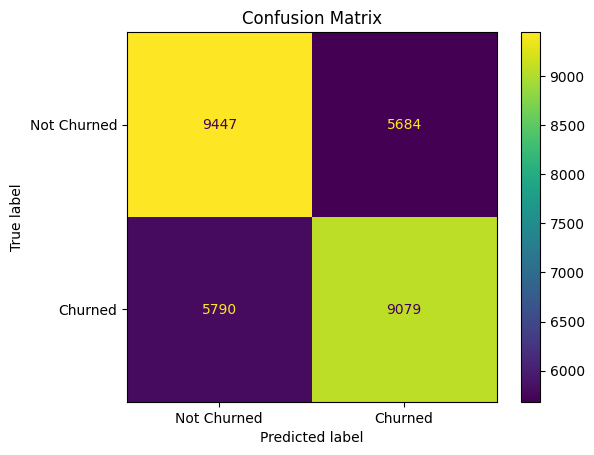

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = rf_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Not Churned', 'Churned'])
plt.title('Confusion Matrix')
plt.show()

## Precision calculation

In [20]:
from sklearn.metrics import accuracy_score

rf_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, rf_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.6175


**Why Accuracy is an Appropriate Metric Here:** Accuracy measures the proportion of all predictions (both churned and not churned) that the model gets correct. It can be misleading on imbalanced datasets, for example, if 95% of customers don't churn, a model that always predicts \"not churned\" would score 95% accuracy while being useless. However, our dataset is nearly balanced (~50% churn, ~50% not churned), so accuracy is not skewed by class frequency and provides a fair, intuitive measure of overall model performance. We still report it alongside AUC and the confusion matrix, since accuracy alone does not distinguish between the business costs of false positives (unnecessary retention offers) and false negatives (missed churners).

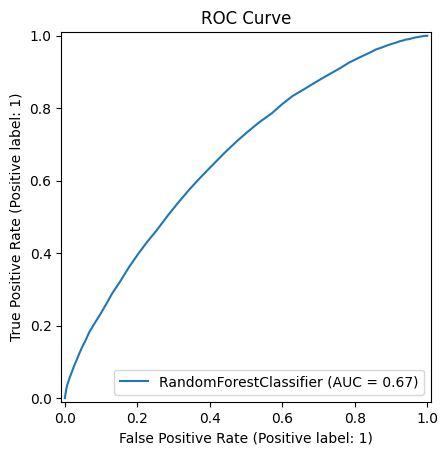

In [21]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.title('ROC Curve')
plt.show()

The ROC curve plots the True Positive Rate (recall on churners) against the False Positive Rate (false alarms on non-churners) across all possible classification thresholds, and the AUC (Area Under the Curve) summarizes this into a single score of 0.67. Unlike accuracy, AUC is largely invariant to class imbalance, both the TPR and FPR are computed separately within each class (churners and non-churners), so the metric reflects the model's ability to rank a churner as riskier than a non-churner regardless of how many of each class exist in the data. An AUC of 0.67 means that if we pick a random churner and a random non-churner, the model assigns the churner a higher risk score about 66% of the time, meaningfully better than the 50% we'd expect from random guessing, though short of a highly precise classifier. For the business, this translates directly into actionable value: rather than contacting customers at random for retention offers, the company can rank all customers by predicted churn risk and focus outreach on the highest-risk segment, capturing a disproportionately large share of actual churners for a fraction of the contact volume, turning a previously untargeted retention budget into a focused, higher-return investment.